In [2]:
import pandas as pd
from babel.dates import parse_date
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima, ARIMA, model_selection
import numpy as np
from sklearn.model_selection import ParameterGrid
import kaggle as ka
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error

In [3]:
ka.api.authenticate()

ka.api.dataset_download_files('htagholdings/property-sales', path='..', unzip= True)

Dataset URL: https://www.kaggle.com/datasets/htagholdings/property-sales


In [4]:
df = pd.read_csv('raw_sales.csv', parse_dates = True, dayfirst= True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   datesold      29580 non-null  object
 1   postcode      29580 non-null  int64 
 2   price         29580 non-null  int64 
 3   propertyType  29580 non-null  object
 4   bedrooms      29580 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB


In [6]:
df.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [7]:
df = df.rename(columns= {'datesold':'date', 'propertyType':'type'})
df.head()

,date,postcode,price,type,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [8]:
df

,date,postcode,price,type,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3
...,...,...,...,...,...
29575,2019-07-25 00:00:00,2900,500000,unit,3
29576,2019-07-25 00:00:00,2612,560000,unit,2
29577,2019-07-26 00:00:00,2912,464950,unit,2
29578,2019-07-26 00:00:00,2601,589000,unit,2


In [9]:
df.loc[df['bedrooms']== 0, 'bedrooms'] = np.nan

In [10]:
df

,date,postcode,price,type,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4.0
1,2007-02-27 00:00:00,2906,290000,house,3.0
2,2007-03-07 00:00:00,2905,328000,house,3.0
3,2007-03-09 00:00:00,2905,380000,house,4.0
4,2007-03-21 00:00:00,2906,310000,house,3.0
...,...,...,...,...,...
29575,2019-07-25 00:00:00,2900,500000,unit,3.0
29576,2019-07-25 00:00:00,2612,560000,unit,2.0
29577,2019-07-26 00:00:00,2912,464950,unit,2.0
29578,2019-07-26 00:00:00,2601,589000,unit,2.0


In [11]:
avg_price_by_bed = df.groupby('bedrooms')['price'].mean()

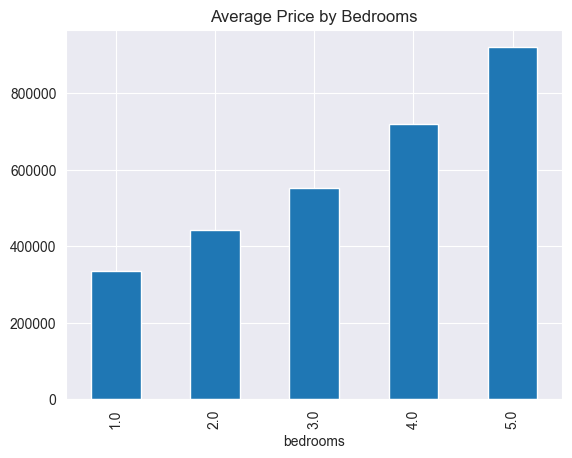

In [12]:
avg_price_by_bed.plot(kind='bar', title='Average Price by Bedrooms')
plt.show()

In [13]:
df.groupby('postcode')['price'].mean()

postcode
2600    1.028204e+06
2601    5.404449e+05
2602    6.957188e+05
2603    1.028642e+06
2604    6.476409e+05
2605    7.861751e+05
2606    5.698613e+05
2607    6.947164e+05
2609    1.447000e+05
2611    6.421450e+05
2612    6.454111e+05
2614    6.091664e+05
2615    5.062134e+05
2616    4.492727e+05
2617    5.266716e+05
2618    1.081111e+06
2620    2.872982e+05
2900    4.174579e+05
2902    5.444455e+05
2903    5.434755e+05
2904    5.993130e+05
2905    5.057797e+05
2906    5.112580e+05
2911    7.247956e+05
2912    5.219604e+05
2913    5.894083e+05
2914    6.234308e+05
Name: price, dtype: float64

In [14]:
df['price'].mean()

np.float64(609736.262204192)

In [15]:
df['price'].median()

np.float64(550000.0)

<Axes: >

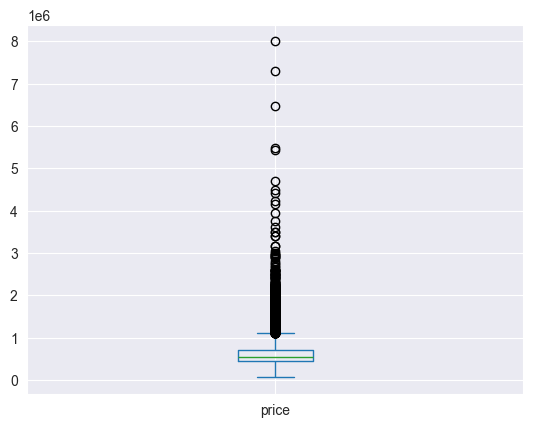

In [16]:
df['price'].plot(kind='box')

<Axes: xlabel='bedrooms', ylabel='price'>

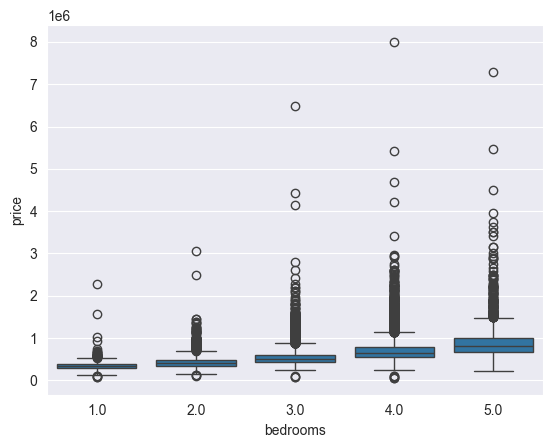

In [17]:
sns.boxplot(x = 'bedrooms', y = 'price', data = df)

In [18]:
df = df.dropna()

In [19]:
df['bedrooms'].value_counts()

bedrooms
3.0    11933
4.0    10442
2.0     3598
5.0     1950
1.0     1627
Name: count, dtype: int64

In [20]:
numeric_feature = df[['price', 'bedrooms']]

In [21]:
numeric_feature.corr()

,price,bedrooms
price,1.000000,0.486524
bedrooms,0.486524,1.000000


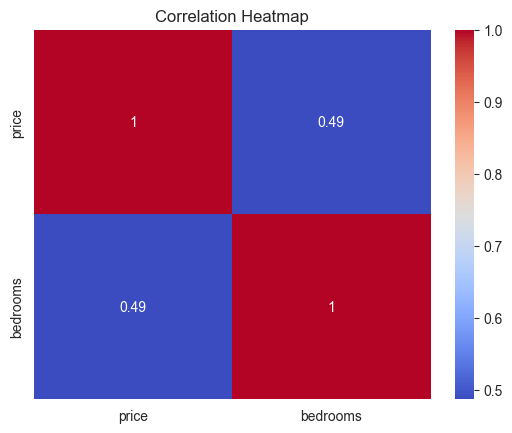

In [22]:
sns.heatmap(data=numeric_feature.corr(numeric_only= True), annot=True , cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

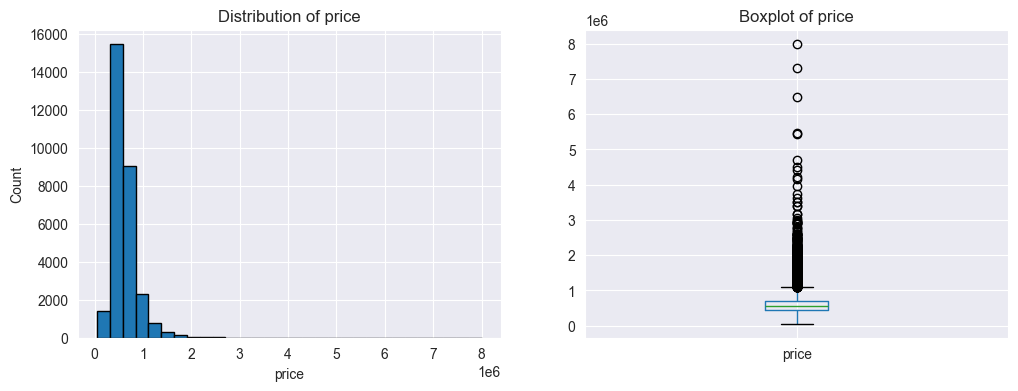

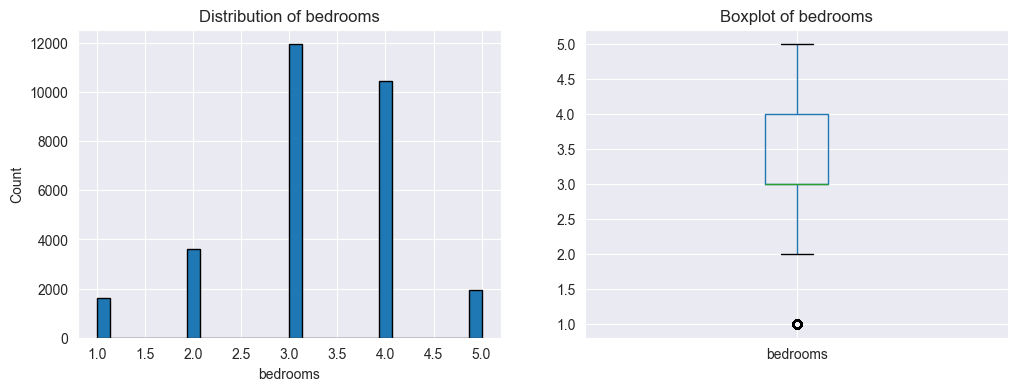

In [23]:
for col in numeric_feature:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    df[col].hist(bins=30, edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")

    plt.show()

In [24]:
df[col]

0        4.0
1        3.0
2        3.0
3        4.0
4        3.0
        ... 
29575    3.0
29576    2.0
29577    2.0
29578    2.0
29579    2.0
Name: bedrooms, Length: 29550, dtype: float64

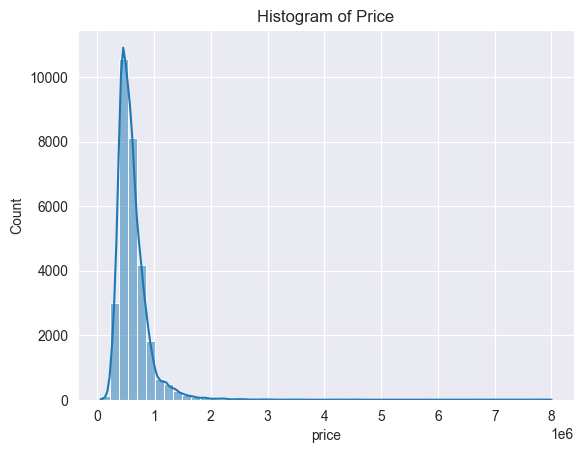

In [25]:
sns.histplot(data=df['price'],bins=50, kde= True)
plt.title('Histogram of Price')
plt.show()

In [26]:
df['log_price'] = np.log1p(df['price'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_26420\3115414603.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_price'] = np.log1p(df['price'])


In [27]:
df['date']= pd.to_datetime(df['date'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_26420\3786899582.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date']= pd.to_datetime(df['date'])


In [28]:
monthly = df.resample('ME', on='date').agg({'price':'median'})

In [29]:
monthly = df.resample('ME', on='date').agg({
    'price': 'median',
    'bedrooms': lambda x: round(x.median()),
    'type': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'postcode': lambda x: x.mode()[0] if not x.mode().empty else np.nan
}).reset_index()

In [30]:
monthly

,date,price,bedrooms,type,postcode
0,2007-02-28,407500.0,4,house,2607
1,2007-03-31,328000.0,3,house,2905
2,2007-04-30,465000.0,4,house,2606
3,2007-05-31,339500.0,3,house,2902
4,2007-06-30,451000.0,4,house,2606
...,...,...,...,...,...
145,2019-03-31,607000.0,3,house,2615
146,2019-04-30,623472.0,3,house,2615
147,2019-05-31,632500.0,3,house,2615
148,2019-06-30,671000.0,4,house,2617


C:\Users\Admin\AppData\Local\Temp\ipykernel_26420\908858239.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


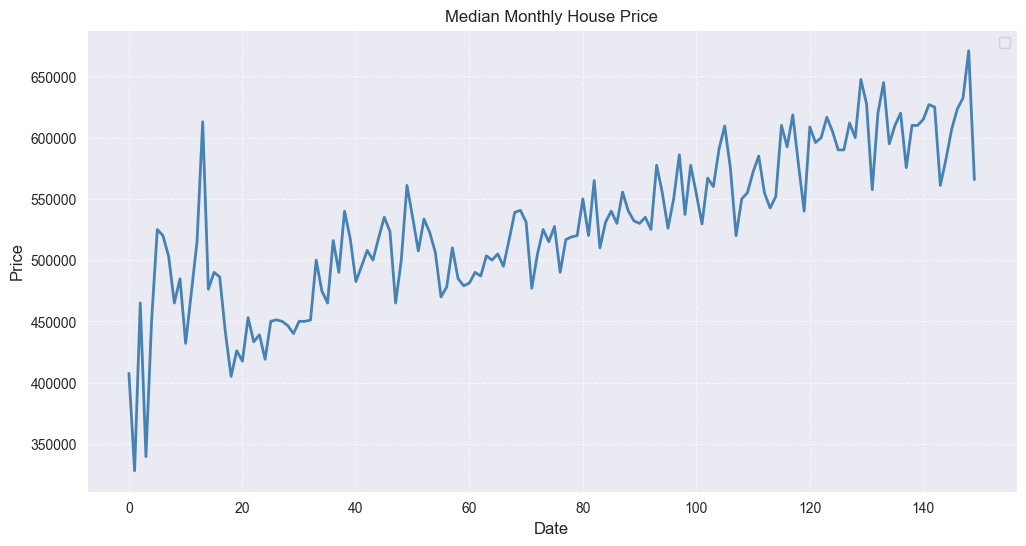

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly['price'], color='steelblue', linewidth=2)
plt.title('Median Monthly House Price')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

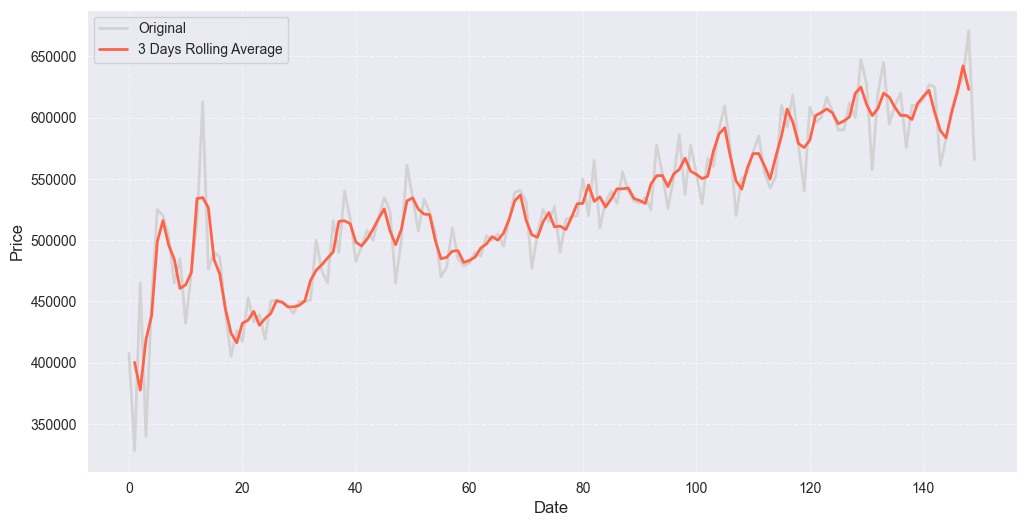

In [32]:
monthly['rolling']= monthly['price'].rolling(window=3, center=True).mean()
plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly['price'], color='lightgray', linewidth=2, label= 'Original')
plt.plot(monthly.index, monthly['rolling'], color='tomato', linewidth=2, label= '3 Days Rolling Average')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [33]:
df['month'] = df['date'].dt.to_period('M')

C:\Users\Admin\AppData\Local\Temp\ipykernel_26420\14857827.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['date'].dt.to_period('M')


In [34]:
monthly_df = (
    df.groupby('month').agg(
        price=('price', 'median'),
        avg_bedrooms=('bedrooms', 'mean'),
        house_ratio=('type', lambda x: (x == 'house').mean()),
        sales_count = ('price', 'count')
    )
    .reset_index()
)

In [35]:
monthly_df['month'] = monthly_df['month'].dt.to_timestamp()
monthly_df.set_index('month', inplace=True)

In [36]:
monthly_df.head()

,price,avg_bedrooms,house_ratio,sales_count
month,,,,
2007-02-01,407500.0,3.500000,1.000000,2
2007-03-01,328000.0,3.333333,1.000000,3
2007-04-01,465000.0,3.666667,1.000000,3
2007-05-01,339500.0,3.000000,1.000000,2
2007-06-01,451000.0,3.333333,0.833333,6


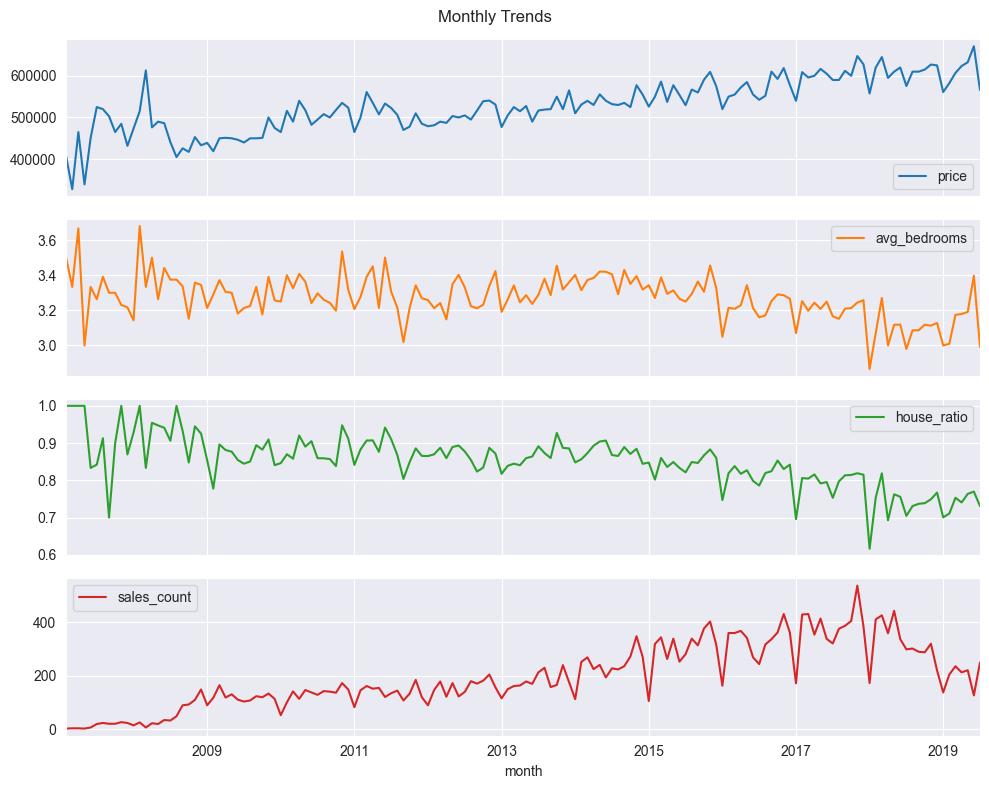

In [37]:
monthly_df[['price', 'avg_bedrooms', 'house_ratio', 'sales_count']].plot(
    subplots=True, figsize=(10, 8), title='Monthly Trends'
)
plt.tight_layout()
plt.show()

In [38]:
train_size = int(len(monthly_df) * 0.85)
train = monthly_df.iloc[:train_size]
test = monthly_df.iloc[train_size:]

In [39]:
train

,price,avg_bedrooms,house_ratio,sales_count
month,,,,
2007-02-01,407500.0,3.500000,1.000000,2
2007-03-01,328000.0,3.333333,1.000000,3
2007-04-01,465000.0,3.666667,1.000000,3
2007-05-01,339500.0,3.000000,1.000000,2
2007-06-01,451000.0,3.333333,0.833333,6
...,...,...,...,...
2017-04-01,600000.0,3.243626,0.815864,353
2017-05-01,616600.0,3.208232,0.791768,413
2017-06-01,605000.0,3.249258,0.795252,337


In [40]:
y_train = train['price']
y_test  = test['price']
X_train = train[['avg_bedrooms', 'house_ratio', 'sales_count']]
X_test  = test[['avg_bedrooms', 'house_ratio', 'sales_count']]

print(f"Train: {len(train)} | Test: {len(test)}")
print("Train range:", train.index.min(), "→", train.index.max())
print("Test range:", test.index.min(), "→", test.index.max())

Train: 127 | Test: 23
Train range: 2007-02-01 00:00:00 → 2017-08-01 00:00:00
Test range: 2017-09-01 00:00:00 → 2019-07-01 00:00:00


In [41]:
auto_model = auto_arima(
    y=y_train,
    exogenous=X_train,
    seasonal=True,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    max_p=3, max_q=3, max_P=2, max_Q=2,
    max_order=None,
    information_criterion='aic'
)
print("Best model order:", auto_model.order)
print("Best seasonal order:", auto_model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3016.462, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2992.316, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3000.981, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3014.653, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2993.195, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2994.121, Time=0.15 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2992.752, Time=0.12 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=2992.407, Time=0.06 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=2994.188, Time=0.22 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=3018.284, Time=0.04 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=2993.234, Time=0.09 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=2993.921, Time=0.16 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=3001.042, Time=0.06 sec
 ARIMA(2,1,1)(1,0,0)[12]

In [42]:
model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = model.fit(disp=False)
print(sarimax_fit.summary())

C:\Users\Admin\PyCharmMiscProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\PyCharmMiscProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                        SARIMAX Results                                        
Dep. Variable:                                   price   No. Observations:                  127
Model:             SARIMAX(1, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood               -1138.168
Date:                                 Mon, 02 Feb 2026   AIC                           2292.336
Time:                                         13:17:35   BIC                           2313.257
Sample:                                     02-01-2007   HQIC                          2300.805
                                          - 08-01-2017                                         
Covariance Type:                                   opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
avg_bedrooms  1.347e+05   5.67e+04      2.375      0.018    2.36e+04  

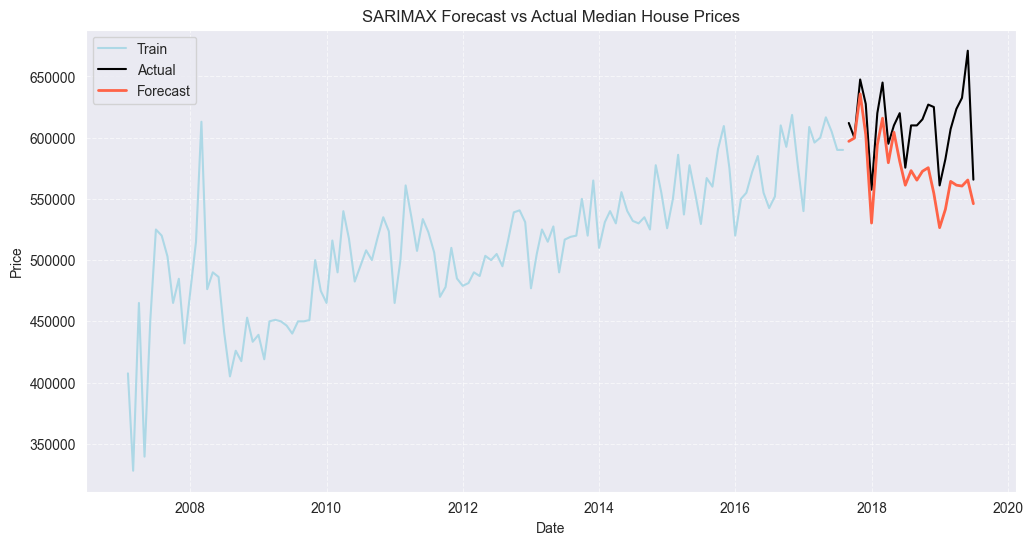

In [43]:
forecast = sarimax_fit.predict(
        start=len(y_train),
        end=len(y_train) + len(y_test) - 1,
        exog=X_test
)

plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Train', color='lightblue')
plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_test.index, forecast, label='Forecast', color='tomato', linewidth=2)
plt.title("SARIMAX Forecast vs Actual Median House Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [44]:
root_mean_squared_error(y_test, forecast)

43410.08225882589